In [1]:
from chembl_webresource_client.new_client import new_client
import pandas as pd
import numpy as np
activity = new_client.activity
Ki_data = activity.filter(
    target_chembl_id = "CHEMBL251",
    standard_type = "Ki",
    standard_relation="=",
    standard_units="nM",
)
df = pd.DataFrame(Ki_data)
df.head()

,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,...,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
0,None,None,32555,[],CHEMBL644471,Antagonist activity against recombinant human ...,F,None,None,BAO_0000192,...,Homo sapiens,Adenosine receptor A2a,9606,None,None,Ki,nM,UO_0000065,None,112.0
1,None,None,36246,[],CHEMBL644471,Antagonist activity against recombinant human ...,F,None,None,BAO_0000192,...,Homo sapiens,Adenosine receptor A2a,9606,None,None,Ki,nM,UO_0000065,None,431.0
2,None,None,36255,[],CHEMBL644471,Antagonist activity against recombinant human ...,F,None,None,BAO_0000192,...,Homo sapiens,Adenosine receptor A2a,9606,None,None,Ki,nM,UO_0000065,None,595.0
3,None,None,38692,[],CHEMBL644471,Antagonist activity against recombinant human ...,F,None,None,BAO_0000192,...,Homo sapiens,Adenosine receptor A2a,9606,None,None,Ki,nM,UO_0000065,None,2370.0
4,None,None,38792,[],CHEMBL643209,Displacement of [3H]ZM-241385 from human adeno...,B,None,None,BAO_0000192,...,Homo sapiens,Adenosine receptor A2a,9606,None,None,Ki,nM,UO_0000065,None,57.0


In [2]:
df.shape

(6586, 46)

In [3]:
cols = [
    "molecule_chembl_id",
    "canonical_smiles",
    "standard_value",
    "standard_units"
]

df_1 = df[cols]
df_1 = df_1.dropna(subset=["canonical_smiles", "standard_value"])
df_1.head()

,molecule_chembl_id,canonical_smiles,standard_value,standard_units
0,CHEMBL17002,CCCn1c(=O)c2nc(-c3ccc(OCC(=O)Nc4ccc(C(C)=O)cc4...,112.0,nM
1,CHEMBL17341,CCCn1c(=O)c2nc(-c3ccc(OCC(=O)Nc4ccccc4C(C)=O)c...,431.0,nM
2,CHEMBL27041,CCCn1c(=O)c2nc(-c3ccc(OCC(=O)O)cc3)[nH]c2n(CCC...,595.0,nM
3,CHEMBL16724,C=CCn1c(=O)c2nc(-c3ccc(OCC(=O)O)cc3)[nH]c2n(CC...,2370.0,nM
4,CHEMBL132806,CC(C)CCn1cc2c(nc(NC(=O)Cc3ccccc3)n3nc(-c4ccco4...,57.0,nM


In [4]:
df_1.shape

(6586, 4)

In [11]:
df_1["standard_value"] = pd.to_numeric(df_1["standard_value"], errors="coerce")
df_1["pKi"] = 9-np.log10(df_1["standard_value"])
df_1 = df_1.dropna(subset=["standard_value"])
df_1.head()

,molecule_chembl_id,canonical_smiles,standard_value,standard_units,pKi,fp
0,CHEMBL17002,CCCn1c(=O)c2nc(-c3ccc(OCC(=O)Nc4ccc(C(C)=O)cc4...,112.0,nM,6.950782,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,CHEMBL17341,CCCn1c(=O)c2nc(-c3ccc(OCC(=O)Nc4ccccc4C(C)=O)c...,431.0,nM,6.365523,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,CHEMBL27041,CCCn1c(=O)c2nc(-c3ccc(OCC(=O)O)cc3)[nH]c2n(CCC...,595.0,nM,6.225483,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,CHEMBL16724,C=CCn1c(=O)c2nc(-c3ccc(OCC(=O)O)cc3)[nH]c2n(CC...,2370.0,nM,5.625252,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,CHEMBL132806,CC(C)CCn1cc2c(nc(NC(=O)Cc3ccccc3)n3nc(-c4ccco4...,57.0,nM,7.244125,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [6]:
df_1.shape

(6586, 5)

<Axes: >

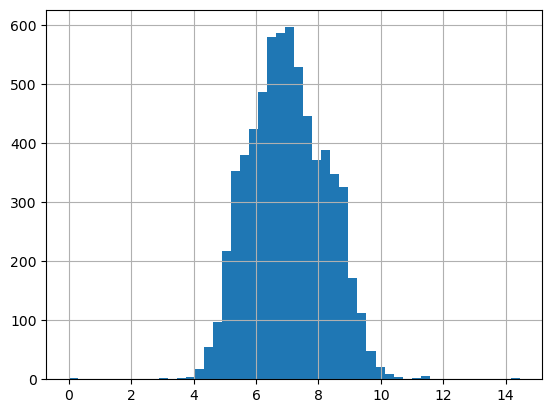

In [15]:
df_1['pKi'].hist(bins=50)

In [10]:
import rdkit
print(rdkit.__version__)

2025.09.6


In [12]:
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
import numpy as np

# Create generator once
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=2048
)

def smiles_to_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        fp = morgan_gen.GetFingerprint(mol)
        return np.array(fp)
    return None

df_1['fp'] = df_1['canonical_smiles'].apply(smiles_to_fp)

df_1 = df_1[df_1['fp'].notna()]
X = np.vstack(df_1['fp'].values)
y = df_1['pKi'].values

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2: 0.7308966774900264
RMSE: 0.6213112882481654
